In [1]:
import pandas as pd
import os

In [2]:
cwd= os.getcwd()
print(cwd)
BASE_DIR= os.path.join(cwd,"..")

data= os.path.join(BASE_DIR, "data", "concat_for_eda.csv")

/home/hngoc/thesis/microcytic-reduced/notebooks


In [3]:
df= pd.read_csv(data)
# df= pd.read_excel(data)
print(df)
print(df.shape)

        Hb   MCV   Fe  Ferritin  Transferin  TSAT (%)    CRP Chẩn đoán  \
0     86.0  76.6  3.1    1062.0       170.0       2.9  174.8  ACD, IDA   
1    114.0  78.5  2.2     457.0       145.0       8.5   15.3       ACD   
2     84.0  75.5  2.6     445.3        93.0      15.6  120.1       ACD   
3    115.0  79.6  1.7    1151.0       125.0       7.6    9.9       ACD   
4     90.0  57.3  2.9    2009.0       116.0      14.0   62.9       ACD   
..     ...   ...  ...       ...         ...       ...    ...       ...   
256  109.0  84.9  5.7      27.3       264.0      12.1    NaN  ACD, IDA   
257   26.0  52.2  3.0       2.8         NaN       NaN    NaN  ACD, IDA   
258   56.0  63.6  2.6      15.1       227.0       6.4    NaN       IDA   
259   17.0  55.0  2.8       2.3         NaN       NaN    0.3       IDA   
260   51.0  45.1  1.0       5.9         NaN       NaN    2.5  ACD, IDA   

     Tiền sử hoặc bệnh kèm theo   RBC  ...  HbS  HbE  Hb khác  alpha_gen  \
0                          True   N

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hb                          261 non-null    float64
 1   MCV                         260 non-null    float64
 2   Fe                          241 non-null    float64
 3   Ferritin                    239 non-null    float64
 4   Transferin                  180 non-null    float64
 5   TSAT (%)                    184 non-null    float64
 6   CRP                         198 non-null    float64
 7   Chẩn đoán                   261 non-null    object 
 8   Tiền sử hoặc bệnh kèm theo  261 non-null    bool   
 9   RBC                         95 non-null     float64
 10  MCH                         28 non-null     float64
 11  MCHC                        101 non-null    float64
 12  RDW-CV                      78 non-null     float64
 13  TIBC                        2 non-n

### Descriptive Statistics by Diagnosis Group

In [5]:
labels = ["ACD", "IDA", "Alpha thalassemia", "Beta thalassemia"]
exclude = labels + ["Giới_nữ"]
numeric_cols = df.select_dtypes(include='number').columns.difference(exclude).tolist()

for label in labels:
    subset = df[df[label] == 1][numeric_cols]
    n = len(subset)
    print(f"{label} (n={n})")
    print(subset.describe().round(2).to_string())

ACD (n=176)
          CRP      Fe  Ferritin      Hb  Hb khác   HbA1  HbA2  HbBart  HbE  HbF  HbH  HbS  MCH    MCHC     MCV    RBC  RDW-CV  Ret-He   TIBC  TSAT (%)  Transferin  alpha_gen  beta_gen
count  167.00  174.00    174.00  176.00      0.0  10.00  9.00     0.0  0.0  0.0  0.0  0.0  0.0   16.00  176.00  15.00    8.00    2.00   2.00    164.00      164.00       16.0      16.0
mean    96.49    3.47    915.69   88.67      NaN  98.15  1.84     NaN  NaN  NaN  NaN  NaN  NaN  290.25   72.45   3.11   21.05   68.15  64.80     12.80      153.96        0.0       0.0
std     90.92    1.99   1190.65   19.28      NaN   0.37  0.39     NaN  NaN  NaN  NaN  NaN  NaN   30.65    8.76   1.00    2.39   40.66  12.16     10.11       47.49        0.0       0.0
min      0.30    1.00      1.93   26.00      NaN  97.20  1.50     NaN  NaN  NaN  NaN  NaN  NaN  250.00   45.10   1.45   15.60   39.40  56.20      1.50       58.00        0.0       0.0
25%     25.10    2.40    281.35   79.75      NaN  98.10  1.60     Na

### Missing Value Rate by Diagnosis Group
Heatmap showing the percentage of missing values for each feature within each diagnosis group. Supports the argument for not imputing — each diagnosis group has a different missing data pattern.

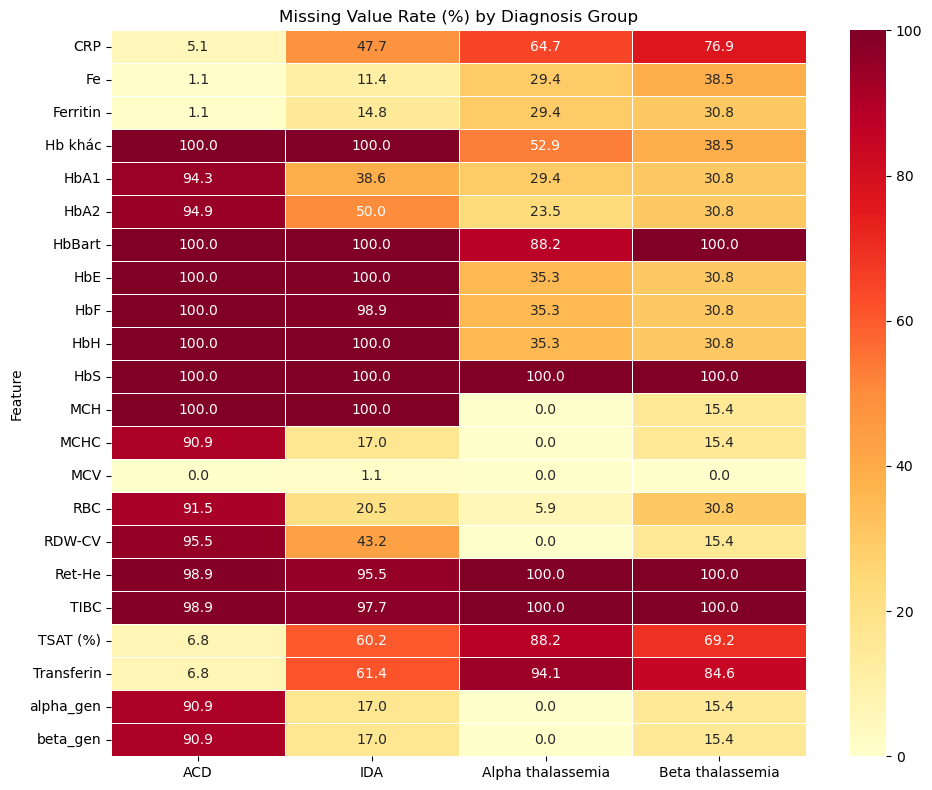

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

labels = ["ACD", "IDA", "Alpha thalassemia", "Beta thalassemia"]
exclude = labels + ["Giới_nữ"]
numeric_cols = df.select_dtypes(include='number').columns.difference(exclude).tolist()

missing_by_diag = pd.DataFrame()
for label in labels:
    subset = df[df[label] == 1][numeric_cols]
    missing_pct = (subset.isnull().sum() / len(subset) * 100).round(1)
    missing_by_diag[label] = missing_pct

missing_by_diag = missing_by_diag[missing_by_diag.max(axis=1) > 0]

plt.figure(figsize=(10, 8))
sns.heatmap(missing_by_diag, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5)
plt.title("Missing Value Rate (%) by Diagnosis Group")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("missing_by_diagnosis.png", dpi=300)
plt.show()

### Shapiro-Wilk Normality Test
Test normality of each feature within each diagnosis group. If most groups reject normality (p<0.05), this justifies using non-parametric tests (Kruskal-Wallis) instead of ANOVA.

In [ ]:
from scipy.stats import shapiro
import warnings

labels = ["ACD", "IDA", "Alpha thalassemia", "Beta thalassemia"]
exclude = labels + ["Giới_nữ"]
numeric_cols = df.select_dtypes(include='number').columns.difference(exclude).tolist()

shapiro_results = []

for col in numeric_cols:
    for label in labels:
        vals = df[df[label] == 1][col].dropna()
        if len(vals) >= 3:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                stat, p = shapiro(vals)
            shapiro_results.append({
                "Feature": col,
                "Group": label,
                "W-statistic": round(stat, 4),
                "p-value": round(p, 6),
                "Normal": "Yes" if p >= 0.05 else "No"
            })

shapiro_df = pd.DataFrame(shapiro_results)

non_normal_count = shapiro_df[shapiro_df["Normal"] == "No"].shape[0]
total_tests = shapiro_df.shape[0]
print(f"{non_normal_count}/{total_tests} tests reject normality (p<0.05)")
print(f"→ Justifies using Kruskal-Wallis (non-parametric) instead of ANOVA\n")

summary = shapiro_df.pivot_table(index="Feature", columns="Group", values="Normal", aggfunc="first")
print(summary)

### Kruskal-Wallis Test
Compare the distribution of each feature across the 4 diagnosis groups (ACD, IDA, Alpha thalassemia, Beta thalassemia).

In [12]:
from scipy.stats import kruskal
import warnings

labels = ["ACD", "IDA", "Alpha thalassemia", "Beta thalassemia"]
exclude = labels + ["Giới_nữ"]+["MCH", "TIBC","Ret-He", "HbF", "HbBart", "HbS", "Hb khác"]
numeric_cols = df.select_dtypes(include='number').columns.difference(exclude).tolist()

kw_results = []

for col in numeric_cols:
    groups = []
    for label in labels:
        vals = df[df[label] == 1][col].dropna()
        if len(vals) >= 3:
            groups.append(vals)

    if len(groups) >= 2:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            stat, p = kruskal(*groups)

        if not pd.isna(stat):
            kw_results.append({
                "Feature": col,
                "H-statistic": round(stat, 4),
                "p-value": round(p, 6),
                "Significant": "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
            })

kw_df = pd.DataFrame(kw_results).sort_values("p-value")
print(kw_df.to_string(index=False))

sig_features = kw_df[kw_df["Significant"] != ""]["Feature"].tolist()
print(f"\nStatistically significant features (p<0.05): {sig_features}")

   Feature  H-statistic  p-value Significant
        Hb      60.7250 0.000000         ***
  Ferritin      78.5102 0.000000         ***
      HbA1      41.1225 0.000000         ***
 alpha_gen      50.0809 0.000000         ***
  beta_gen     116.0000 0.000000         ***
Transferin      22.4914 0.000002         ***
       MCV      27.3276 0.000005         ***
      HbA2      27.3993 0.000005         ***
        Fe      25.6708 0.000011         ***
       RBC      25.1881 0.000014         ***
  TSAT (%)      20.8716 0.000029         ***
       CRP      23.1857 0.000037         ***
      MCHC       9.4431 0.023944           *
       HbE       4.0661 0.043751           *
       HbH       3.8325 0.050269            
    RDW-CV       1.4131 0.702466            

Statistically significant features (p<0.05): ['Hb', 'Ferritin', 'HbA1', 'alpha_gen', 'beta_gen', 'Transferin', 'MCV', 'HbA2', 'Fe', 'RBC', 'TSAT (%)', 'CRP', 'MCHC', 'HbE']


In [ ]:
import scikit_posthocs as sp
import warnings

labels = ["ACD", "IDA", "Alpha thalassemia", "Beta thalassemia"]
exclude = labels + ["Giới_nữ"]
numeric_cols = df.select_dtypes(include='number').columns.difference(exclude).tolist()

sig_features = kw_df[kw_df["Significant"] != ""]["Feature"].tolist()

for col in sig_features:
    melted = []
    for label in labels:
        vals = df[df[label] == 1][col].dropna()
        for v in vals:
            melted.append({"Group": label, "Value": v})

    melted_df = pd.DataFrame(melted)

    if melted_df.empty or melted_df["Group"].nunique() < 2:
        continue

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        dunn = sp.posthoc_dunn(melted_df, val_col="Value", group_col="Group", p_adjust="bonferroni")

    sig_pairs = []
    for i in range(len(dunn.index)):
        for j in range(i + 1, len(dunn.columns)):
            g1, g2 = dunn.index[i], dunn.columns[j]
            p = dunn.iloc[i, j]
            if p < 0.05:
                star = "***" if p < 0.001 else "**" if p < 0.01 else "*"
                sig_pairs.append(f"  {g1} vs {g2}: p={p:.6f} {star}")

    if sig_pairs:
        print(f"\n{col}")
        for pair in sig_pairs:
            print(pair)

### Univariable Distribution

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_copy= df.copy()

X_y_don= df_copy.drop(columns= labels)


In [ ]:
null_X = X_y_don.drop(columns= ["Chẩn đoán"])
null_counts = null_X.isnull().sum()

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
null_counts.plot(kind='bar')

# Xoay trục x 45 độ
plt.xticks(rotation=80)

plt.title('Number of Missing Values per Column')
plt.xlabel('Columns')
plt.ylabel('Count of Nulls')

plt.tight_layout()
plt.show()

In [ ]:
for i in range(len(X_y_don)):
    col_name= X_y_don.columns[i]
    plt.figure()
    sns.boxplot(data= X_y_don, x=col_name, hue= "Chẩn đoán")
    plt.legend(
    title= f"Distribution of {col_name} by diagnosis",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
    plt.show()

In [ ]:
plt.figure()
sns.countplot(data= X_y_don, x= "Giới_nữ", hue= "Chẩn đoán")
plt.legend(
    title= "Distribution of gender by diagnosis",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

In [ ]:
# làm cái này với điều kiện no null values

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = X_y_don.drop("Chẩn đoán", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=X_y_don["Chẩn đoán"])

In [ ]:
from sklearn.manifold import TSNE
# làm cái này với điều kiện no null values

X = df.drop("Chẩn đoán", axis=1)
X_embedded = TSNE(n_components=2).fit_transform(X)

plt.figure()
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=df["Chẩn đoán"])
plt.legend(
    title="Chẩn đoán",
    bbox_to_anchor=(1.05, 1),  # đẩy sang phải
    loc='upper left'
)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

# làm cái này với điều kiện no null values

X = df.drop("Chẩn đoán", axis=1)
X_embedded = TSNE(n_components=2).fit_transform(X)
score = silhouette_score(X_embedded, df["Chẩn đoán"])
print(score)

In [ ]:
plt.figure()
# làm cái này với điều kiện no null values

X = df.drop("Chẩn đoán", axis=1)
X_embedded = TSNE(n_components=2).fit_transform(X)

ax = sns.kdeplot(
    x=X_embedded[:,0],
    y=X_embedded[:,1],
    hue=df["Chẩn đoán"]
)

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
# làm cái này với điều kiện no null values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X_scaled)

sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=clusters)

In [ ]:
sns.histplot(df["Chẩn đoán"])
plt.xticks(rotation=90)
plt.show()

In [ ]:
y = df[["ACD", "IDA", "Alpha thalassemia" ,"Beta thalassemia"]]

counts = y.value_counts()

print(counts)

In [ ]:
import pandas as pd

# Các nhãn
labels = ["ACD", "IDA", "Alpha thalassemia", "Beta thalassemia"]

# Ma trận đồng xuất hiện
co_matrix = pd.DataFrame(
    0,
    index=labels,
    columns=labels
)

# Đếm số lần xuất hiện cùng nhau
for _, row in y.iterrows():

    active_labels = row[row == 1].index.tolist()

    for l1 in active_labels:
        for l2 in active_labels:
            co_matrix.loc[l1, l2] += 1

print(co_matrix)